In [ ]:
# Cell 1 — Install and imports
!pip install -q astroquery astropy pandas numpy matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astroquery.gaia import Gaia
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric
from scipy.optimize import curve_fit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.8 MB/s eta 0:00:00


In [ ]:
# Cell 2 — Download the Gaia DR3 sample
MAX_ROWS = 25_000

Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"

query = f"""
SELECT TOP {MAX_ROWS}
    source_id,
    ra,
    dec,
    l,
    b,
    parallax,
    parallax_error,
    pmra,
    pmdec,
    radial_velocity,
    radial_velocity_error
FROM gaiadr3.gaia_source
WHERE radial_velocity IS NOT NULL
  AND radial_velocity_error IS NOT NULL
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND parallax > 0.1
  AND parallax_over_error > 10
  AND radial_velocity_error < 20
  AND ABS(b) < 20
ORDER BY random_index
"""

print("Querying Gaia DR3...")
df = Gaia.launch_job_async(query).get_results().to_pandas()
print(f"Retrieved {len(df):,} stars.")
display(df.head())

df.to_csv("gaia_raw_6d_sample.csv", index=False)

Querying Gaia DR3...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
Retrieved 25,000 stars.


,source_id,ra,dec,l,b,parallax,parallax_error,pmra,pmdec,radial_velocity,radial_velocity_error
0,4040949706019490560,265.229363,-36.358205,353.159523,-3.052137,0.352725,0.029665,-0.570184,-5.683394,-39.548756,2.289071
1,1823532754729083392,300.805804,20.601006,59.466608,-5.523316,0.886435,0.020054,9.675645,0.425116,-32.939175,5.852169
2,6068055453656132736,198.685803,-54.101028,306.383346,8.614470,1.351779,0.018469,-3.107003,1.482269,0.551207,2.958417
3,527154051013641088,8.303528,64.995242,121.006407,2.191647,0.703967,0.018081,-3.440837,1.194513,-48.187603,3.265717
4,6084196726724370560,202.890673,-46.281027,310.127249,16.029387,2.821713,0.093853,12.731613,2.493211,66.639244,1.595879


In [ ]:
# Cell 3 — Transform Gaia observables to Galactocentric kinematics
data = df.dropna(
    subset=[
        "source_id", "ra", "dec", "parallax", "parallax_error",
        "pmra", "pmdec", "radial_velocity"
    ]
).copy()

distance_pc = 1000.0 / data["parallax"].to_numpy()

coords = SkyCoord(
    ra=data["ra"].to_numpy() * u.deg,
    dec=data["dec"].to_numpy() * u.deg,
    distance=distance_pc * u.pc,
    pm_ra_cosdec=data["pmra"].to_numpy() * u.mas / u.yr,
    pm_dec=data["pmdec"].to_numpy() * u.mas / u.yr,
    radial_velocity=data["radial_velocity"].to_numpy() * u.km / u.s,
    frame="icrs"
)

galcen = coords.transform_to(Galactocentric())

x = galcen.x.to_value(u.kpc)
y = galcen.y.to_value(u.kpc)
z = galcen.z.to_value(u.kpc)

vx = galcen.v_x.to_value(u.km / u.s)
vy = galcen.v_y.to_value(u.km / u.s)
vz = galcen.v_z.to_value(u.km / u.s)

R = np.hypot(x, y)
vR = (x * vx + y * vy) / R
vphi = -(x * vy - y * vx) / R

kinematics = pd.DataFrame({
    "source_id": data["source_id"].to_numpy(),
    "R_kpc": R,
    "z_kpc": z,
    "vR_km_s": vR,
    "vphi_km_s": vphi,
    "vz_km_s": vz
})

print(f"Processed {len(kinematics):,} stars.")
print(f"Median vphi: {kinematics['vphi_km_s'].median():.1f} km/s")
display(kinematics.head())

kinematics.to_csv("gaia_processed_kinematics.csv", index=False)

Processed 25,000 stars.
Median vphi: 224.2 km/s


,source_id,R_kpc,z_kpc,vR_km_s,vphi_km_s,vz_km_s
0,4040949706019490560,5.322165,-0.137347,24.779024,184.025689,-23.743211
1,1823532754729083392,7.613467,-0.089240,59.839338,222.817249,-31.557895
2,6068055453656132736,7.710342,0.130494,-22.635268,238.719606,13.986810
3,527154051013641088,8.936264,0.076997,-27.347435,221.409112,15.479463
4,6084196726724370560,7.906492,0.118097,-77.667792,208.366594,26.690276


In [ ]:
# Cell 4 — Select disk stars and construct the binned observed curve
disk = kinematics[
    (kinematics["R_kpc"] >= 3.0) &
    (kinematics["R_kpc"] <= 15.0) &
    (np.abs(kinematics["z_kpc"]) <= 1.0) &
    (np.abs(kinematics["vz_km_s"]) <= 100.0) &
    (kinematics["vphi_km_s"] >= 50.0) &
    (kinematics["vphi_km_s"] <= 400.0)
].copy()

bin_edges = np.arange(3.0, 15.5, 0.5)
disk["R_bin"] = pd.cut(disk["R_kpc"], bins=bin_edges, include_lowest=True)

rotation_curve = (
    disk.groupby("R_bin", observed=True)
    .agg(
        R_kpc=("R_kpc", "median"),
        vphi_km_s=("vphi_km_s", "median"),
        velocity_scatter=("vphi_km_s", "std"),
        star_count=("source_id", "size")
    )
    .reset_index(drop=True)
)

rotation_curve = rotation_curve[rotation_curve["star_count"] >= 20].copy()
rotation_curve["vphi_error_km_s"] = np.maximum(
    1.253 * rotation_curve["velocity_scatter"] / np.sqrt(rotation_curve["star_count"]),
    5.0
)

print(f"Disk stars retained: {len(disk):,}")
display(rotation_curve)
rotation_curve.to_csv("gaia_binned_vphi_curve.csv", index=False)

Disk stars retained: 24,421


,R_kpc,vphi_km_s,velocity_scatter,star_count,vphi_error_km_s
1,3.801668,192.783611,65.280165,29,15.189145
2,4.314200,195.784029,52.302825,90,6.908042
3,4.791978,205.607429,46.859106,239,5.000000
4,5.291725,211.585987,40.420042,537,5.000000
5,5.775807,213.532353,37.648406,886,5.000000
6,6.268092,219.944649,33.757477,1280,5.000000
7,6.775443,224.048995,30.308842,2046,5.000000
8,7.274859,225.376929,28.401060,3347,5.000000
9,7.762514,228.088755,26.594314,4803,5.000000
10,8.236816,226.476069,24.976096,4509,5.000000


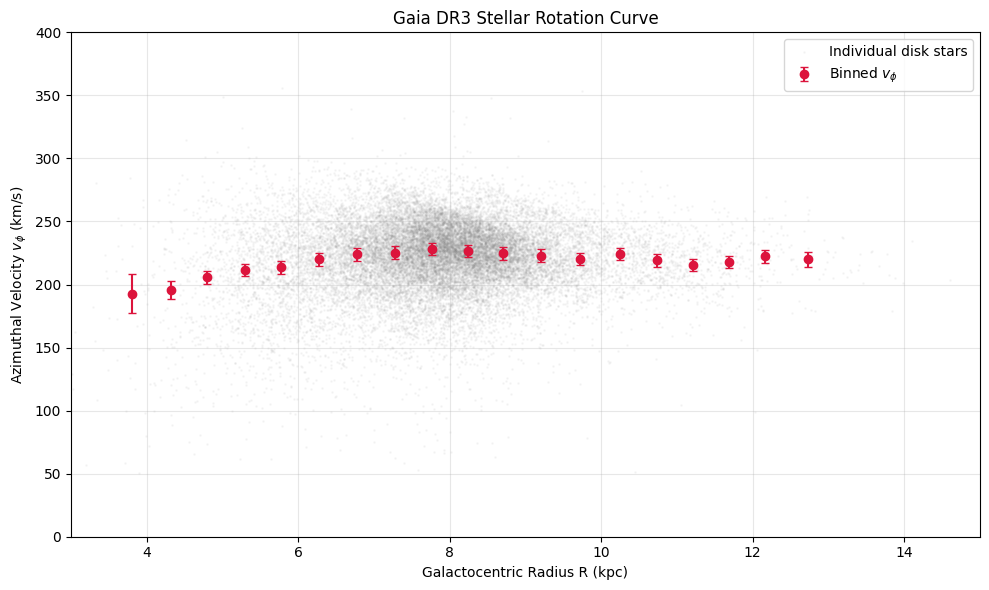

In [ ]:
# Cell 5 — Plot observed vphi rotation curve
plt.figure(figsize=(10, 6))
plt.scatter(
    disk["R_kpc"], disk["vphi_km_s"],
    s=1, alpha=0.05, color="gray", label="Individual disk stars"
)
plt.errorbar(
    rotation_curve["R_kpc"], rotation_curve["vphi_km_s"],
    yerr=rotation_curve["vphi_error_km_s"], fmt="o",
    color="crimson", capsize=3, label=r"Binned $v_\phi$"
)
plt.xlabel("Galactocentric Radius R (kpc)")
plt.ylabel(r"Azimuthal Velocity $v_\phi$ (km/s)")
plt.title("Gaia DR3 Stellar Rotation Curve")
plt.xlim(3, 15)
plt.ylim(0, 400)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6 — Exploratory Jeans asymmetric-drift correction
# Assumptions: axisymmetry, steady state, negligible tilt term <v_R v_z>,
# and a tracer-density proxy from selected-star counts in annular bins.

jeans_curve = (
    disk.groupby("R_bin", observed=True)
    .agg(
        R_kpc=("R_kpc", "median"),
        vphi_sq=("vphi_km_s", lambda s: np.mean(s**2)),
        vR_sq=("vR_km_s", lambda s: np.mean(s**2)),
        star_count=("source_id", "size")
    )
    .reset_index(drop=True)
)

jeans_curve = jeans_curve[jeans_curve["star_count"] >= 20].copy()
Rj = jeans_curve["R_kpc"].to_numpy()

# For fixed-width annuli, surface-density proxy nu is proportional to N/R.
nu_proxy = jeans_curve["star_count"].to_numpy() / Rj
vR_sq = jeans_curve["vR_sq"].to_numpy()
vphi_sq = jeans_curve["vphi_sq"].to_numpy()

dlnnu_dlnR = np.gradient(np.log(nu_proxy), np.log(Rj))
dlnvR2_dlnR = np.gradient(np.log(vR_sq), np.log(Rj))

vc_sq = vphi_sq - vR_sq * (1.0 + dlnnu_dlnR + dlnvR2_dlnR)

jeans_curve["vc_km_s"] = np.sqrt(np.maximum(vc_sq, 0.0))
# The derivative and selection-function uncertainty dominate; use a conservative 10% floor.
jeans_curve["vc_error_km_s"] = np.maximum(0.10 * jeans_curve["vc_km_s"], 8.0)

jeans_curve = jeans_curve[
    np.isfinite(jeans_curve["vc_km_s"]) &
    (jeans_curve["vc_km_s"] > 0)
].copy()

jeans_curve.to_csv("gaia_jeans_corrected_curve.csv", index=False)
display(jeans_curve)

,R_kpc,vphi_sq,vR_sq,star_count,vc_km_s,vc_error_km_s
2,4.314200,38776.753914,4169.060988,90,84.372748,8.437275
3,4.791978,42467.973637,3250.027548,239,151.888366,15.188837
4,5.291725,45667.374592,2390.121343,537,185.333418,18.533342
5,5.775807,45738.522315,2138.082851,886,194.210281,19.421028
6,6.268092,48220.370198,1907.275027,1280,202.932952,20.293295
7,6.775443,49884.544519,1661.158185,2046,204.506699,20.450670
8,7.274859,50832.525906,1491.226290,3347,208.807549,20.880755
9,7.762514,51311.340128,1377.571214,4803,223.172907,22.317291
10,8.236816,50848.584136,1312.562790,4509,239.928366,23.992837
11,8.709831,50537.846563,1225.519945,3061,252.787270,25.278727


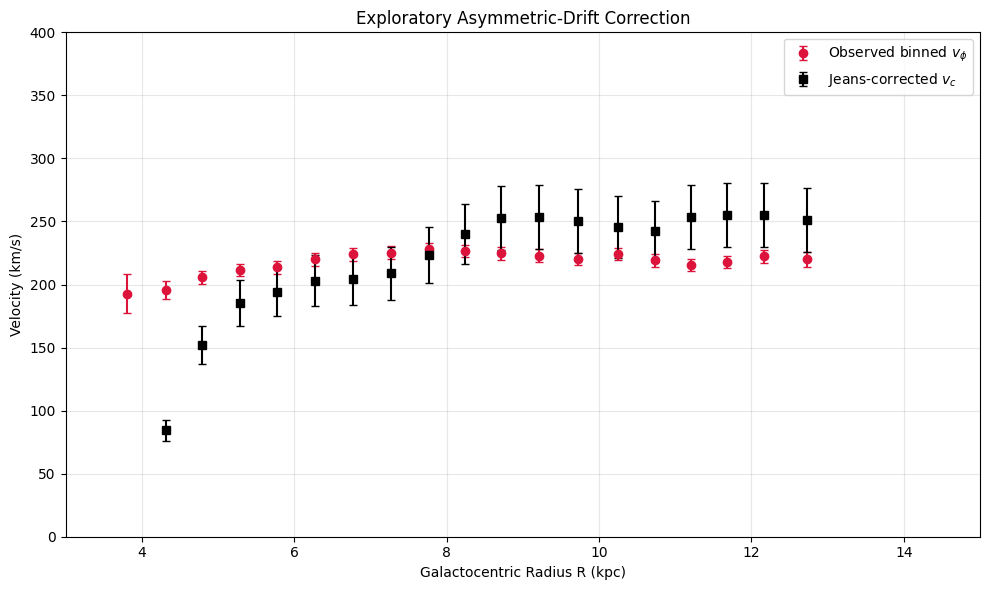

In [ ]:
# Cell 7 — Compare observed vphi with the Jeans-corrected circular speed
plt.figure(figsize=(10, 6))
plt.errorbar(
    rotation_curve["R_kpc"], rotation_curve["vphi_km_s"],
    yerr=rotation_curve["vphi_error_km_s"], fmt="o",
    color="crimson", capsize=3, label=r"Observed binned $v_\phi$"
)
plt.errorbar(
    jeans_curve["R_kpc"], jeans_curve["vc_km_s"],
    yerr=jeans_curve["vc_error_km_s"], fmt="s",
    color="black", capsize=3, label=r"Jeans-corrected $v_c$"
)
plt.xlabel("Galactocentric Radius R (kpc)")
plt.ylabel("Velocity (km/s)")
plt.title("Exploratory Asymmetric-Drift Correction")
plt.xlim(3, 15)
plt.ylim(0, 400)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 8 — Hernquist bulge and Miyamoto-Nagai disk model
G = 4.30091e-6  # kpc (km/s)^2 / solar mass

# Fixed baryonic assumptions.
M_BULGE, A_BULGE = 0.9e10, 0.7
M_STELLAR_DISK, A_STELLAR, B_STELLAR = 5.0e10, 3.5, 0.30
M_GAS_DISK, A_GAS, B_GAS = 1.0e10, 4.0, 0.10

def bulge_velocity(R):
    """Hernquist bulge: v^2 = G M R / (R+a)^2."""
    R = np.asarray(R)
    return np.sqrt(G * M_BULGE * R / (R + A_BULGE)**2)

def miyamoto_nagai_velocity(R, mass, a, b):
    """Miyamoto-Nagai circular velocity in the Galactic plane z=0."""
    R = np.asarray(R)
    v_sq = G * mass * R**2 / (R**2 + (a + b)**2)**1.5
    return np.sqrt(np.maximum(v_sq, 0.0))

def baryonic_velocity(R):
    v_bulge = bulge_velocity(R)
    v_stars = miyamoto_nagai_velocity(R, M_STELLAR_DISK, A_STELLAR, B_STELLAR)
    v_gas = miyamoto_nagai_velocity(R, M_GAS_DISK, A_GAS, B_GAS)
    return np.sqrt(v_bulge**2 + v_stars**2 + v_gas**2)

In [ ]:
# Cell 9 — Define NFW halo and total model
H0 = 67.4 / 1000.0  # km/s/kpc
rho_crit = 3.0 * H0**2 / (8.0 * np.pi * G)

def nfw_velocity_and_mass(R, log10_M200, concentration):
    """NFW halo velocity and enclosed dark mass at radius R."""
    R = np.asarray(R)
    M200 = 10.0**log10_M200
    r200 = (3.0 * M200 / (4.0 * np.pi * 200.0 * rho_crit))**(1.0 / 3.0)
    r_s = r200 / concentration

    def f(x):
        return np.log1p(x) - x / (1.0 + x)

    M_enclosed = M200 * f(R / r_s) / f(concentration)
    v_halo = np.sqrt(G * M_enclosed / R)
    return v_halo, M_enclosed

def total_velocity_model(R, log10_M200, concentration):
    v_halo, _ = nfw_velocity_and_mass(R, log10_M200, concentration)
    return np.sqrt(baryonic_velocity(R)**2 + v_halo**2)

In [ ]:
# Cell 10 — Fit Hernquist + MN disks + NFW to Jeans-corrected data
R_data = jeans_curve["R_kpc"].to_numpy()
v_data = jeans_curve["vc_km_s"].to_numpy()
v_error = jeans_curve["vc_error_km_s"].to_numpy()

best_params, covariance = curve_fit(
    total_velocity_model,
    R_data,
    v_data,
    sigma=v_error,
    absolute_sigma=True,
    p0=[12.0, 12.0],
    bounds=([10.5, 1.0], [13.5, 40.0]),
    maxfev=30000
)

log10_M200, concentration = best_params
parameter_errors = np.sqrt(np.diag(covariance))

print(f"log10(M200/Msun) = {log10_M200:.3f} +/- {parameter_errors[0]:.3f}")
print(f"NFW concentration c = {concentration:.2f} +/- {parameter_errors[1]:.2f}")
print(f"M200 = {10**log10_M200:.3e} solar masses")

if np.isclose(log10_M200, 13.5, atol=0.01):
    print("Warning: M200 reached the upper fitting bound; it is not a robust total-halo measurement.")

log10(M200/Msun) = 13.500 +/- 7.755
NFW concentration c = 2.37 +/- 14.80
M200 = 3.162e+13 solar masses


Reduced chi-square = 14.13


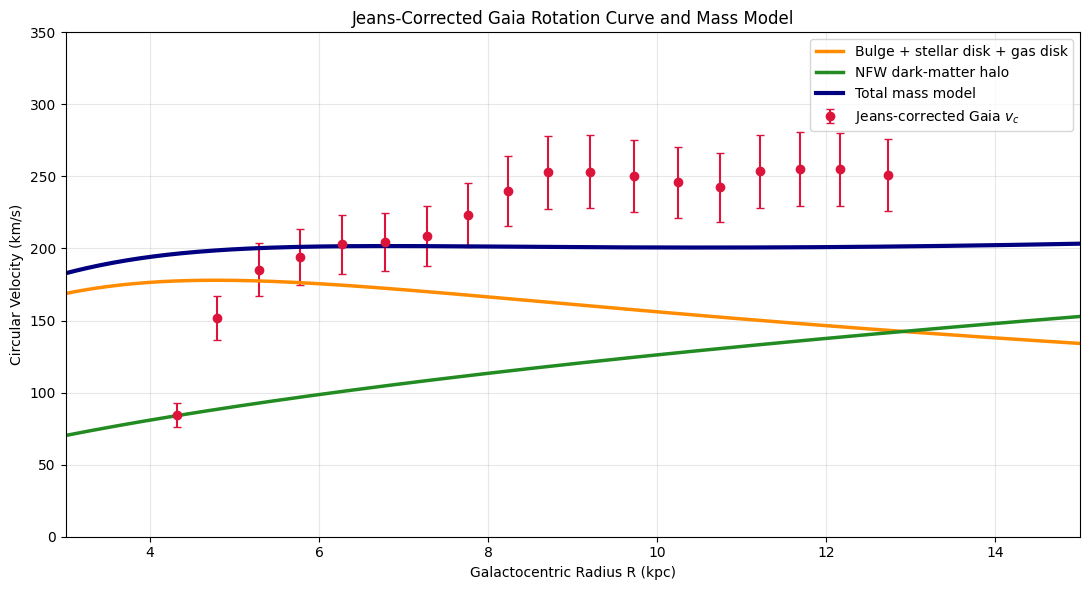

In [ ]:
# Cell 11 — Final component decomposition and fit quality
R_model = np.linspace(3.0, 15.0, 300)

v_bulge_model = bulge_velocity(R_model)
v_stellar_model = miyamoto_nagai_velocity(
    R_model, M_STELLAR_DISK, A_STELLAR, B_STELLAR
)
v_gas_model = miyamoto_nagai_velocity(
    R_model, M_GAS_DISK, A_GAS, B_GAS
)
v_baryon_model = baryonic_velocity(R_model)
v_halo_model, M_halo_model = nfw_velocity_and_mass(R_model, log10_M200, concentration)
v_total_model = total_velocity_model(R_model, log10_M200, concentration)

v_total_data = total_velocity_model(R_data, log10_M200, concentration)
residuals = v_data - v_total_data
chi_square = np.sum((residuals / v_error)**2)
dof = len(v_data) - 2

print(f"Reduced chi-square = {chi_square / dof:.2f}")

plt.figure(figsize=(11, 6))
plt.errorbar(
    R_data, v_data, yerr=v_error,
    fmt="o", color="crimson", capsize=3,
    label=r"Jeans-corrected Gaia $v_c$"
)
plt.plot(R_model, v_baryon_model, color="darkorange", lw=2.5, label="Bulge + stellar disk + gas disk")
plt.plot(R_model, v_halo_model, color="forestgreen", lw=2.5, label="NFW dark-matter halo")
plt.plot(R_model, v_total_model, color="navy", lw=3, label="Total mass model")
plt.xlabel("Galactocentric Radius R (kpc)")
plt.ylabel("Circular Velocity (km/s)")
plt.title("Jeans-Corrected Gaia Rotation Curve and Mass Model")
plt.xlim(3, 15)
plt.ylim(0, 350)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("gaia_jeans_miyamoto_nagai_nfw_fit.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Cell 12 — Save the enclosed dark-matter result
v_halo_data, M_dark_enclosed = nfw_velocity_and_mass(R_data, log10_M200, concentration)

# Spherical-equivalent dynamical mass is supplied only as a diagnostic.
# It is not the model's total mass because the disk is flattened.
M_dyn_spherical_equiv = R_data * v_data**2 / G

results = pd.DataFrame({
    "R_kpc": R_data,
    "Jeans_corrected_vc_km_s": v_data,
    "vc_error_km_s": v_error,
    "baryonic_velocity_km_s": baryonic_velocity(R_data),
    "dark_matter_velocity_km_s": v_halo_data,
    "total_model_velocity_km_s": v_total_data,
    "dark_matter_enclosed_Msun": M_dark_enclosed,
    "spherical_equivalent_dynamical_mass_Msun": M_dyn_spherical_equiv
})

results.to_csv("jeans_corrected_dark_matter_profile.csv", index=False)

i_outer = np.argmax(R_data)
print(f"Outermost Gaia radius: {R_data[i_outer]:.2f} kpc")
print(f"Inferred dark matter inside that radius: {M_dark_enclosed[i_outer]:.3e} solar masses")

display(results)

Outermost Gaia radius: 12.73 kpc
Inferred dark matter inside that radius: 5.927e+10 solar masses


,R_kpc,Jeans_corrected_vc_km_s,vc_error_km_s,baryonic_velocity_km_s,dark_matter_velocity_km_s,total_model_velocity_km_s,dark_matter_enclosed_Msun,spherical_equivalent_dynamical_mass_Msun
0,4.314200,84.372748,8.437275,177.489242,83.997089,196.361763,7.077313e+09,7.140758e+09
1,4.791978,151.888366,15.188837,177.973353,88.427707,198.730908,8.712267e+09,2.570416e+10
2,5.291725,185.333418,18.533342,177.478646,92.816468,200.283715,1.059954e+10,4.226145e+10
3,5.775807,194.210281,19.421028,176.285406,96.860067,201.142778,1.259917e+10,5.065202e+10
4,6.268092,202.932952,20.293295,174.561220,100.788423,201.568663,1.480459e+10,6.001782e+10
5,6.775443,204.506699,20.450670,172.414736,104.665121,201.696873,1.725764e+10,6.588589e+10
6,7.274859,208.807549,20.880755,170.062148,108.328904,201.634039,1.984965e+10,7.374908e+10
7,7.762514,223.172907,22.317291,167.624546,111.775023,201.473681,2.254922e+10,8.989281e+10
8,8.236816,239.928366,23.992837,165.180916,115.013513,201.278024,2.533359e+10,1.102458e+11
9,8.709831,252.787270,25.278727,162.714819,118.141276,201.080763,2.826524e+10,1.294076e+11


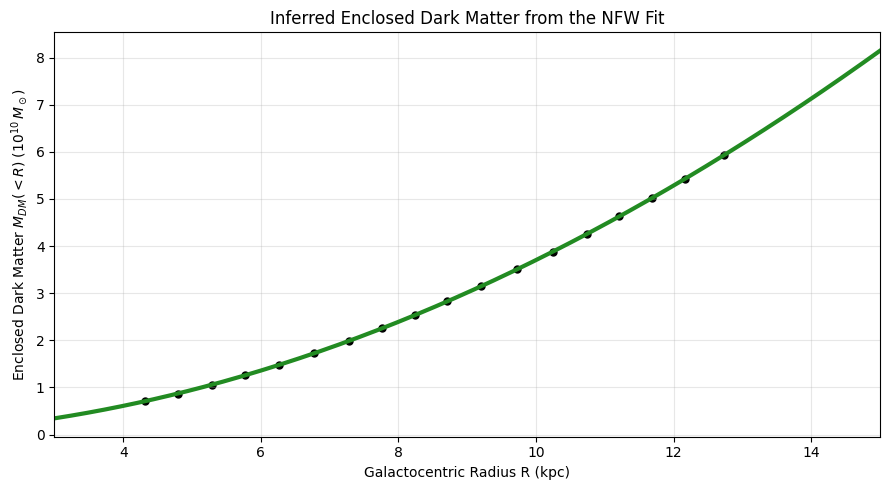

In [ ]:
# Cell 13 — Enclosed dark matter versus radius
plt.figure(figsize=(9, 5))
plt.plot(R_model, M_halo_model / 1e10, color="forestgreen", lw=3)
plt.scatter(R_data, M_dark_enclosed / 1e10, color="black", s=25)
plt.xlabel("Galactocentric Radius R (kpc)")
plt.ylabel(r"Enclosed Dark Matter $M_{DM}(<R)$ ($10^{10}\,M_\odot$)")
plt.title("Inferred Enclosed Dark Matter from the NFW Fit")
plt.xlim(3, 15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("enclosed_dark_matter_jeans_corrected.png", dpi=200, bbox_inches="tight")
plt.show()